# Exercise 2 — Guided transfer learning with CIFAR-10 — Solution

This solution uses sensible default settings. Results can vary by hardware, random seed, and TorchVision version.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

repo_root = Path.cwd().parents[1] if Path.cwd().name == "solutions" else (Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
sys.path.append(str(repo_root / "src"))

from cvis_ml.config import DatasetConfig, ModelConfig, TrainConfig
from cvis_ml.data import CIFAR10DataModule, auto_pin_memory
from cvis_ml.models import TransferModelFactory, count_parameters, describe_trainable_parameters
from cvis_ml.engine import run_transfer_experiment, resolve_device
from cvis_ml.visualization import show_batch, plot_history, show_confusion_matrix, show_misclassified, results_table

torch.manual_seed(42)
np.random.seed(42)
device = resolve_device("auto")
print("Device:", device)
print("DataLoader pin_memory will be:", auto_pin_memory())

Device: cpu
DataLoader pin_memory will be: False


In [2]:
def conv_output_size(input_size: int, kernel_size: int, stride: int = 1, padding: int = 0):
    return int(((input_size + 2 * padding - kernel_size) // stride) + 1)

assert conv_output_size(32, 3, stride=1, padding=1) == 32
assert conv_output_size(32, 3, stride=2, padding=1) == 16

conv = torch.nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1)
x = torch.randn(4, 3, 32, 32)
y = conv(x)
print("Input shape :", tuple(x.shape))
print("Output shape:", tuple(y.shape))

Input shape : (4, 3, 32, 32)
Output shape: (4, 8, 32, 32)


In [3]:
answer_A = """
out_channels=8 means that the convolution produces 8 feature maps from the input image.
Padding=1 compensates for the 3x3 kernel border loss when stride is 1, so the spatial size remains 32x32.
Pretrained CNNs expect a consistent preprocessing pipeline because the learned filters were trained on images with a particular scale and normalization.
"""
print(answer_A)


out_channels=8 means that the convolution produces 8 feature maps from the input image.
Padding=1 compensates for the 3x3 kernel border loss when stride is 1, so the spatial size remains 32x32.
Pretrained CNNs expect a consistent preprocessing pipeline because the learned filters were trained on images with a particular scale and normalization.



c:\Users\gianl\Documents\Code\AUT-RUB_CV4IS_Exercise_2\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train counts: {0: 300, 1: 300, 2: 300, 3: 300, 4: 300, 5: 300, 6: 300, 7: 300, 8: 300, 9: 300}
Val counts: {0: 80, 1: 80, 2: 80, 3: 80, 4: 80, 5: 80, 6: 80, 7: 80, 8: 80, 9: 80}


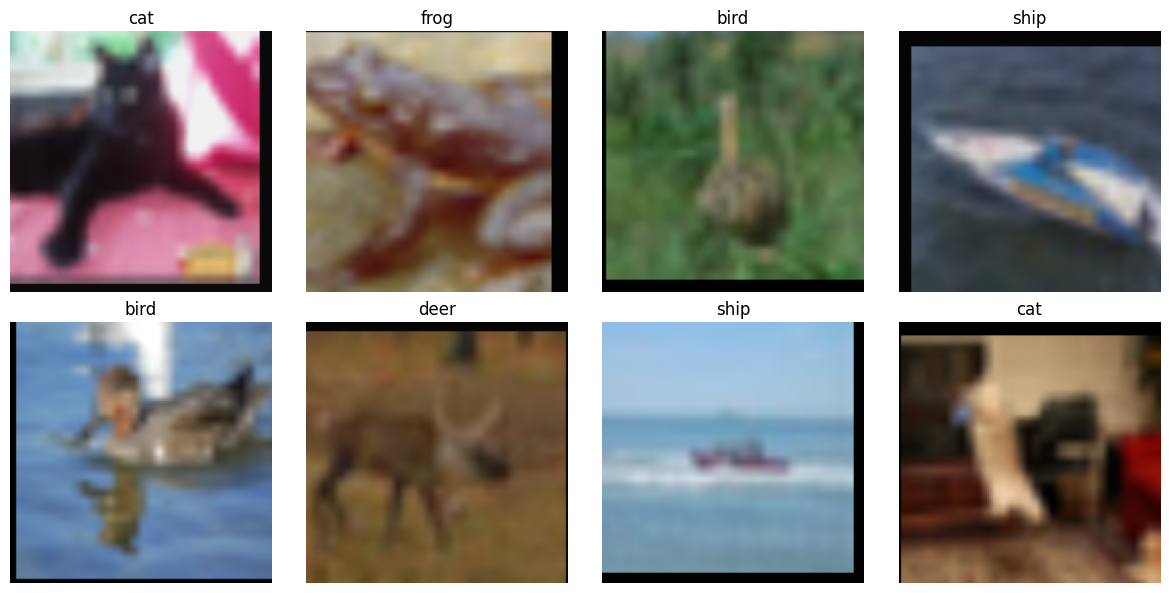

In [4]:
cifar_cfg = DatasetConfig(
    name="cifar10_guided",
    data_root=str(repo_root / "data_cache"),
    image_size=128,
    batch_size=32,
    max_train_samples=3000,
    max_val_samples=800,
    num_workers=0,
    seed=42,
    augment=True,
)
cifar_dm = CIFAR10DataModule(
    root=cifar_cfg.data_root,
    image_size=cifar_cfg.image_size,
    batch_size=cifar_cfg.batch_size,
    num_workers=cifar_cfg.num_workers,
    max_train_samples=cifar_cfg.max_train_samples,
    max_val_samples=cifar_cfg.max_val_samples,
    seed=cifar_cfg.seed,
    augment=cifar_cfg.augment,
)
cifar_data = cifar_dm.setup()
print("Classes:", cifar_data.class_names)
print("Train counts:", cifar_data.train_counts)
print("Val counts:", cifar_data.val_counts)
show_batch(cifar_data.train_loader, cifar_data.class_names, n=8)

In [5]:
answer_B1 = """
RandomHorizontalFlip is plausible for many CIFAR-10 classes because flipping a car, truck, bird, or ship usually preserves the class.
RandomCrop can improve robustness to small translations but may remove important parts if the crop is too aggressive.
ColorJitter can help with lighting variation but may be risky for industrial inspection if color or brightness is part of the acceptance criterion.
Validation augmentation should usually be deterministic so that validation measures model performance rather than random transform behavior.
"""
print(answer_B1)


RandomHorizontalFlip is plausible for many CIFAR-10 classes because flipping a car, truck, bird, or ship usually preserves the class.
RandomCrop can improve robustness to small translations but may remove important parts if the crop is too aggressive.
ColorJitter can help with lighting variation but may be risky for industrial inspection if color or brightness is part of the acceptance criterion.
Validation augmentation should usually be deterministic so that validation measures model performance rather than random transform behavior.



In [6]:
model_cfg = ModelConfig(
    architecture="resnet18",
    strategy="frozen",
    pretrained=True,
    num_classes=cifar_data.num_classes,
)
model = TransferModelFactory.create(
    architecture=model_cfg.architecture,
    strategy=model_cfg.strategy,
    pretrained=model_cfg.pretrained,
    num_classes=model_cfg.num_classes,
)
total_params, trainable_params = count_parameters(model)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
pd.DataFrame(describe_trainable_parameters(model, max_rows=20))

Total parameters: 11181642
Trainable parameters: 5130


,name,shape,numel
0,fc.weight,"(10, 512)",5120
1,fc.bias,"(10,)",10


Training on device: cpu


train:   0%|          | 0/94 [00:00<?, ?it/s]

eval:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.7042485982813733, 'train_acc': 0.42433333333333334, 'val_loss': 1.214168493747711, 'val_acc': 0.6225, 'val_macro_f1': 0.6105887127399847}


train:   0%|          | 0/94 [00:00<?, ?it/s]

...

{'epoch': 2, 'train_loss': 1.0985166335359533, 'train_acc': 0.652, 'val_loss': 1.0406147384643554, 'val_acc': 0.66375, 'val_macro_f1': 0.6590281355864404}


train:   0%|          | 0/94 [00:00<?, ?it/s]

eval:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 3, 'train_loss': 0.9508915638670008, 'train_acc': 0.6913333333333334, 'val_loss': 0.9568743753433228, 'val_acc': 0.67625, 'val_macro_f1': 0.6693042134150161}


eval:   0%|          | 0/25 [00:00<?, ?it/s]

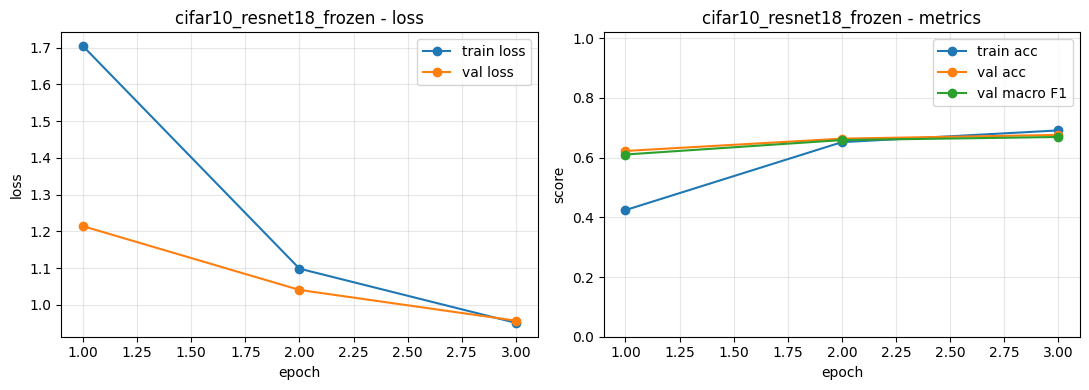

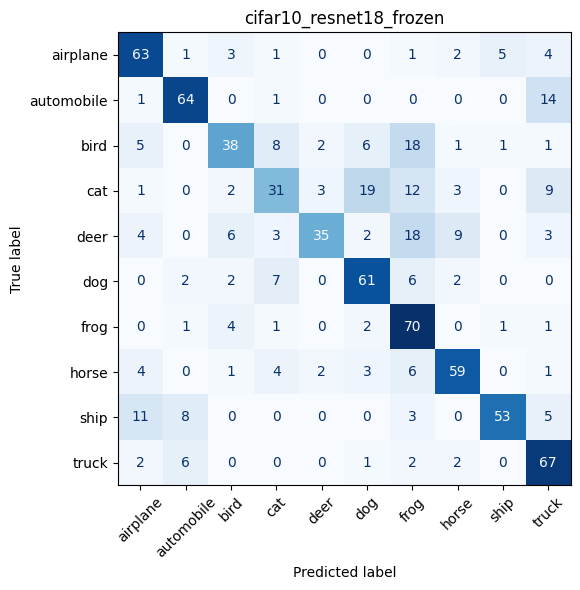

In [7]:
train_cfg = TrainConfig(
    epochs=3,
    learning_rate=1e-3,
    weight_decay=1e-4,
    device="auto",
    use_class_weights=False,
    max_batches_per_epoch=None,
    scheduler=None,
)
result_resnet_frozen = run_transfer_experiment(
    name="cifar10_resnet18_frozen",
    model=model,
    train_loader=cifar_data.train_loader,
    val_loader=cifar_data.val_loader,
    epochs=train_cfg.epochs,
    learning_rate=train_cfg.learning_rate,
    weight_decay=train_cfg.weight_decay,
    device=train_cfg.device,
    max_batches_per_epoch=train_cfg.max_batches_per_epoch,
)
plot_history(result_resnet_frozen.history, title=result_resnet_frozen.name)
show_confusion_matrix(result_resnet_frozen.y_true, result_resnet_frozen.y_pred, cifar_data.class_names, title=result_resnet_frozen.name)

In [8]:
answer_D = """
Validation accuracy should improve across the first epochs if the learning rate is reasonable.
The training loss should decrease because the new classifier head learns task-specific decision boundaries.
If both train and validation performance are low, the model is underfitting or not trained long enough.
If train performance improves strongly but validation stagnates or drops, the model may overfit the subset.
The confusion matrix can reveal class pairs with similar visual appearance, such as cat/dog or automobile/truck.
"""
print(answer_D)


Validation accuracy should improve across the first epochs if the learning rate is reasonable.
The training loss should decrease because the new classifier head learns task-specific decision boundaries.
If both train and validation performance are low, the model is underfitting or not trained long enough.
If train performance improves strongly but validation stagnates or drops, the model may overfit the subset.
The confusion matrix can reveal class pairs with similar visual appearance, such as cat/dog or automobile/truck.



In [9]:
def run_cifar_setting(name, architecture, strategy, epochs, learning_rate, augment=True, max_batches_per_epoch=None):
    dm = CIFAR10DataModule(
        root=cifar_cfg.data_root,
        image_size=cifar_cfg.image_size,
        batch_size=cifar_cfg.batch_size,
        num_workers=cifar_cfg.num_workers,
        max_train_samples=cifar_cfg.max_train_samples,
        max_val_samples=cifar_cfg.max_val_samples,
        seed=cifar_cfg.seed,
        augment=augment,
    )
    data = dm.setup()
    model_x = TransferModelFactory.create(
        architecture=architecture,
        strategy=strategy,
        pretrained=True,
        num_classes=data.num_classes,
    )
    return run_transfer_experiment(
        name=name,
        model=model_x,
        train_loader=data.train_loader,
        val_loader=data.val_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        weight_decay=1e-4,
        device="auto",
        max_batches_per_epoch=max_batches_per_epoch,
    )

experiment_settings = [
    {"name": "resnet18_frozen_lr1e-3_ep4", "architecture": "resnet18", "strategy": "frozen", "epochs": 4, "learning_rate": 1e-3, "augment": True},
    {"name": "resnet18_frozen_lr1e-4_ep4", "architecture": "resnet18", "strategy": "frozen", "epochs": 4, "learning_rate": 1e-4, "augment": True},
]
results = [result_resnet_frozen]
for cfg in experiment_settings:
    print("\nRunning", cfg)
    results.append(run_cifar_setting(**cfg))
results_table(results)


Running {'name': 'resnet18_frozen_lr1e-3_ep4', 'architecture': 'resnet18', 'strategy': 'frozen', 'epochs': 4, 'learning_rate': 0.001, 'augment': True}


c:\Users\gianl\Documents\Code\AUT-RUB_CV4IS_Exercise_2\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training on device: cpu


train:   0%|          | 0/94 [00:00<?, ?it/s]

eval:   0%|          | 0/25 [00:00<?, ?it/s]

...

train:   0%|          | 0/94 [00:00<?, ?it/s]

eval:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 4, 'train_loss': 1.6659203970685919, 'train_acc': 0.47733333333333333, 'val_loss': 1.6399209260940553, 'val_acc': 0.47, 'val_macro_f1': 0.4646177289874348}


eval:   0%|          | 0/25 [00:00<?, ?it/s]

,name,val_acc,val_macro_f1,val_loss,runtime_s
1,resnet18_frozen_lr1e-3_ep4,0.68375,0.673288,0.912704,137.977288
0,cifar10_resnet18_frozen,0.67625,0.669304,0.956874,80.171978
2,resnet18_frozen_lr1e-4_ep4,0.47000,0.464618,1.639921,136.425124


In [10]:
strategy_settings = [
    {"name": "resnet18_partial_lr1e-4_ep3", "architecture": "resnet18", "strategy": "partial", "epochs": 3, "learning_rate": 1e-4, "augment": True},
    {"name": "mobilenet_v3_small_frozen_lr1e-3_ep3", "architecture": "mobilenet_v3_small", "strategy": "frozen", "epochs": 3, "learning_rate": 1e-3, "augment": True},
]
for cfg in strategy_settings:
    print("\nRunning", cfg)
    results.append(run_cifar_setting(**cfg))
results_table(results)


Running {'name': 'resnet18_partial_lr1e-4_ep3', 'architecture': 'resnet18', 'strategy': 'partial', 'epochs': 3, 'learning_rate': 0.0001, 'augment': True}


c:\Users\gianl\Documents\Code\AUT-RUB_CV4IS_Exercise_2\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training on device: cpu


train:   0%|          | 0/94 [00:00<?, ?it/s]

eval:   0%|          | 0/25 [00:00<?, ?it/s]

...

train:   0%|          | 0/94 [00:00<?, ?it/s]

eval:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 3, 'train_loss': 0.9719905631339296, 'train_acc': 0.675, 'val_loss': 0.9928050112724304, 'val_acc': 0.65, 'val_macro_f1': 0.6440964780854718}


eval:   0%|          | 0/25 [00:00<?, ?it/s]

,name,val_acc,val_macro_f1,val_loss,runtime_s
3,resnet18_partial_lr1e-4_ep3,0.81875,0.817020,0.536899,127.214288
1,resnet18_frozen_lr1e-3_ep4,0.68375,0.673288,0.912704,137.977288
0,cifar10_resnet18_frozen,0.67625,0.669304,0.956874,80.171978
4,mobilenet_v3_small_frozen_lr1e-3_ep3,0.65000,0.644096,0.992805,19.348420
2,resnet18_frozen_lr1e-4_ep4,0.47000,0.464618,1.639921,136.425124


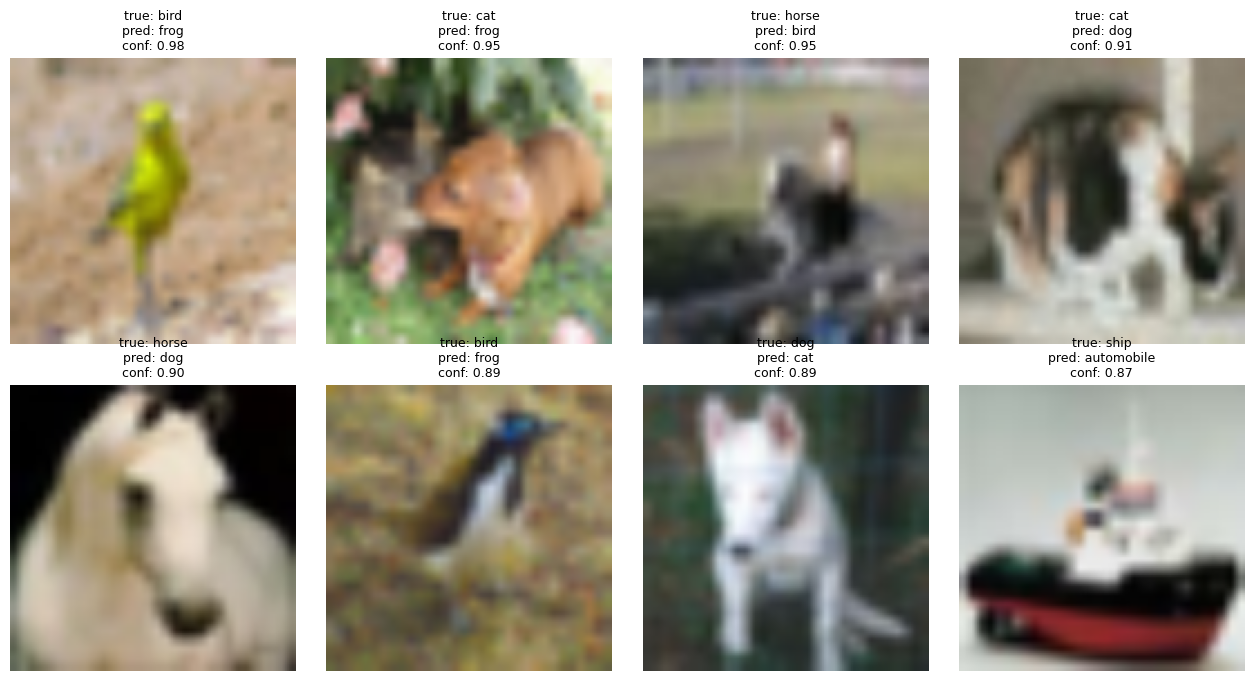

In [11]:
show_misclassified(
    model,
    cifar_data.val_loader,
    cifar_data.class_names,
    device=resolve_device("auto"),
    n=8,
    max_batches=20,
)

In [12]:
final_cifar_report = """
The best baseline depends on runtime and random variation, but a frozen ResNet18 usually gives a reasonable first result.
More epochs generally improve the classifier head until validation performance saturates.
A learning rate of 1e-3 is a good starting point for a frozen head, while partial fine-tuning should usually use a smaller learning rate.
Augmentation can improve robustness but can also make the task harder if the transforms are too aggressive.
MobileNetV3-Small may be attractive when runtime or deployment constraints matter.
With more compute, I would tune learning rate, train longer, test stronger augmentation, and inspect misclassifications systematically.
"""
print(final_cifar_report)


The best baseline depends on runtime and random variation, but a frozen ResNet18 usually gives a reasonable first result.
More epochs generally improve the classifier head until validation performance saturates.
A learning rate of 1e-3 is a good starting point for a frozen head, while partial fine-tuning should usually use a smaller learning rate.
Augmentation can improve robustness but can also make the task harder if the transforms are too aggressive.
MobileNetV3-Small may be attractive when runtime or deployment constraints matter.
With more compute, I would tune learning rate, train longer, test stronger augmentation, and inspect misclassifications systematically.

